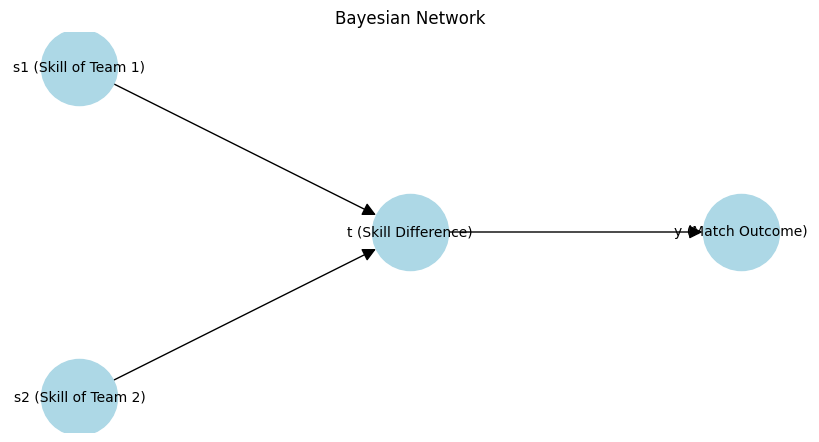

In [6]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a directed graph
G = nx.DiGraph()

# Add nodes
nodes = {
    's1': 's1 (Skill of Team 1)',
    's2': 's2 (Skill of Team 2)',
    't': 't (Skill Difference)',
    'y': 'y (Match Outcome)'
}
for node, label in nodes.items():
    G.add_node(node, label=label)

# Add edges
edges = [('s1', 't'), ('s2', 't'), ('t', 'y')]
G.add_edges_from(edges)

# Get positions for the nodes (can be adjusted as needed)
pos = {
    's1': (0, 2),
    's2': (0, 0),
    't': (2, 1),
    'y': (4, 1)
}

# Draw the graph
plt.figure(figsize=(8, 4))
nx.draw(G, pos, with_labels=False, node_size=3000, node_color="lightblue", arrowsize=20)

# Add labels to nodes
node_labels = {node: label for node, label in nodes.items()}
nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=10)

# Add edge labels if necessary (optional)
edge_labels = {edge: "" for edge in edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Bayesian Network")
plt.show()


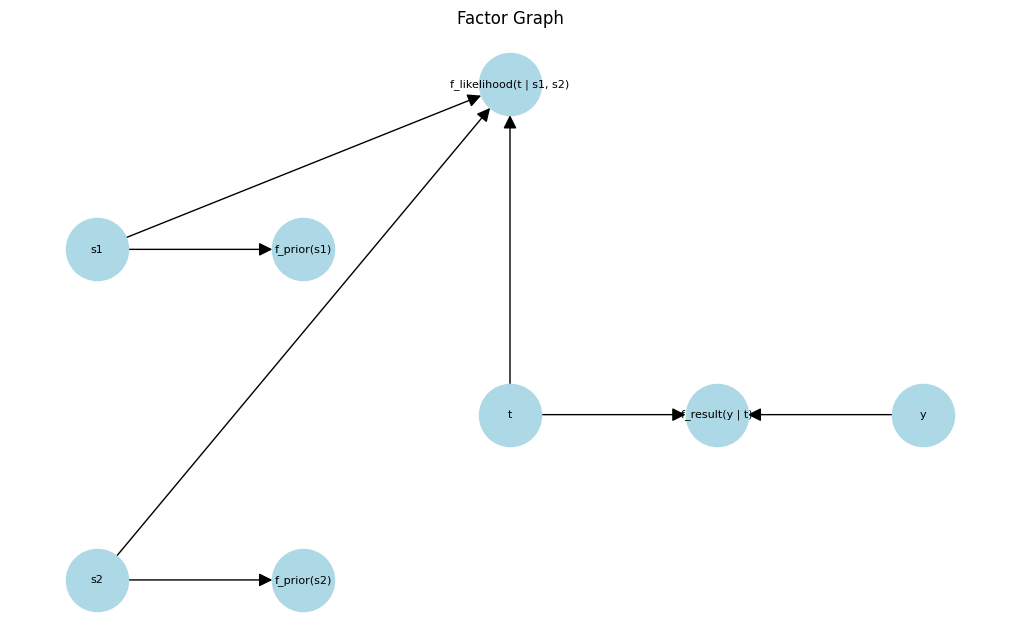

In [7]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a bipartite graph
G = nx.DiGraph()

# Add variable nodes
variable_nodes = {
    's1': 's1',
    's2': 's2',
    't': 't',
    'y': 'y'
}
factor_nodes = {
    'f_prior_s1': 'f_prior(s1)',
    'f_prior_s2': 'f_prior(s2)',
    'f_likelihood': 'f_likelihood(t | s1, s2)',
    'f_result': 'f_result(y | t)'
}

# Add nodes to the graph
for node, label in {**variable_nodes, **factor_nodes}.items():
    G.add_node(node, label=label)

# Add edges
edges = [
    ('s1', 'f_prior_s1'),
    ('s2', 'f_prior_s2'),
    ('s1', 'f_likelihood'),
    ('s2', 'f_likelihood'),
    ('t', 'f_likelihood'),
    ('t', 'f_result'),
    ('y', 'f_result')
]
G.add_edges_from(edges)

# Define positions for better visualization
pos = {
    's1': (0, 3),
    's2': (0, 1),
    't': (4, 2),
    'y': (8, 2),
    'f_prior_s1': (2, 3),
    'f_prior_s2': (2, 1),
    'f_likelihood': (4, 4),
    'f_result': (6, 2)
}

# Draw the graph
plt.figure(figsize=(10, 6))
nx.draw(G, pos, with_labels=False, node_size=2000, node_color="lightblue", arrowsize=20)

# Add labels to nodes
node_labels = {node: label for node, label in {**variable_nodes, **factor_nodes}.items()}
nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=8)

# Add edge labels if necessary (optional)
edge_labels = {edge: "" for edge in edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Factor Graph")
plt.show()


In [1]:
import numpy as np
import pandas as pd
from scipy.stats import norm

# Constants for TrueSkill model
MU0 = 25.0  # Initial mean skill level
SIGMA0 = 8.333  # Initial standard deviation for skill levels
BETA = 4.166  # Scaling parameter for skill differences
SIGMA_T = 1.0  # Match outcome variance
EPSILON = 1e-6  # Small value to avoid division by zero

# Load the Serie A dataset
file_path = 'SerieA.csv'
seriea_data = pd.read_csv(file_path)

# Prepare the dataset for TrueSkill analysis
seriea_data['result'] = seriea_data['score1'] - seriea_data['score2']
seriea_data['outcome'] = seriea_data['result'].apply(lambda x: 1 if x > 0 else (-1 if x < 0 else 0))
matches = seriea_data[['team1', 'team2', 'outcome']]

# Initialize skill priors for each team
teams = set(matches['team1']).union(set(matches['team2']))
skills = {team: {'mu': MU0, 'sigma': SIGMA0} for team in teams}

# Refined function to safely update skills
def safe_update_skills(team1, team2, outcome):
    """Safely update the skills of two teams based on match outcome."""
    # Retrieve current skills
    mu1, sigma1 = skills[team1]['mu'], skills[team1]['sigma']
    mu2, sigma2 = skills[team2]['mu'], skills[team2]['sigma']

    # Compute prior distributions
    delta_mu = mu1 - mu2
    delta_sigma2 = sigma1**2 + sigma2**2 + SIGMA_T**2
    delta_sigma = np.sqrt(delta_sigma2)

    # Update based on the outcome
    if outcome == 1:  # Team 1 wins
        z = max(norm.cdf(delta_mu / delta_sigma), EPSILON)
        v = norm.pdf(delta_mu / delta_sigma) / z
        w = v * (v + delta_mu / delta_sigma)
    elif outcome == -1:  # Team 2 wins
        z = max(norm.cdf(-delta_mu / delta_sigma), EPSILON)
        v = -norm.pdf(delta_mu / delta_sigma) / z
        w = v * (v - delta_mu / delta_sigma)
    else:  # Draw
        z = max(2 * norm.cdf(-abs(delta_mu) / delta_sigma), EPSILON)
        v = -delta_mu / delta_sigma / z
        w = v**2 + (1 - v * abs(delta_mu / delta_sigma)) / z

    # Ensure stability of variance updates
    new_sigma1_sq = sigma1**2 * (1 - w)
    new_sigma2_sq = sigma2**2 * (1 - w)

    # Avoid negative variances
    new_sigma1_sq = max(new_sigma1_sq, EPSILON)
    new_sigma2_sq = max(new_sigma2_sq, EPSILON)

    # Update means and variances
    mu1_new = mu1 + (sigma1**2 * v / delta_sigma)
    mu2_new = mu2 - (sigma2**2 * v / delta_sigma)
    sigma1_new = np.sqrt(new_sigma1_sq)
    sigma2_new = np.sqrt(new_sigma2_sq)

    # Update skills
    skills[team1] = {'mu': mu1_new, 'sigma': sigma1_new}
    skills[team2] = {'mu': mu2_new, 'sigma': sigma2_new}

# Apply updates for all matches
for _, row in matches.iterrows():
    safe_update_skills(row['team1'], row['team2'], row['outcome'])

# Prepare a table of final skill estimates
refined_skill_table = pd.DataFrame([
    {'Team': team, 'Mu': skill['mu'], 'Sigma': skill['sigma']}
    for team, skill in skills.items()
])
refined_skill_table = refined_skill_table.sort_values(by='Mu', ascending=False).reset_index(drop=True)

# Display the skill table
print(refined_skill_table)


          Team            Mu        Sigma
0      Bologna  5.038019e+25        0.001
1     Juventus  4.560582e+24        0.001
2   Fiorentina  2.062472e+19  8589934.592
3     Atalanta  9.121144e+18        0.001
4        Lazio  9.121142e+18        0.001
5     Cagliari  1.687304e+13        0.001
6        Genoa  1.310710e+07        0.001
7     Sassuolo  1.167132e+07        0.001
8         Spal  1.533072e+06        0.001
9    Sampdoria  1.269438e+03        0.001
10      Empoli  4.099034e+01        0.001
11       Parma  1.043788e+01        0.001
12   Frosinone -8.709104e+00        0.001
13        Roma -2.626707e+01        0.001
14      Chievo -2.063897e+07        0.001
15      Napoli -2.064125e+07        0.001
16       Milan -4.127778e+07        0.001
17       Inter -1.031953e+13        0.001
18     Udinese -2.063884e+13        0.001
19      Torino -1.031941e+19        0.001


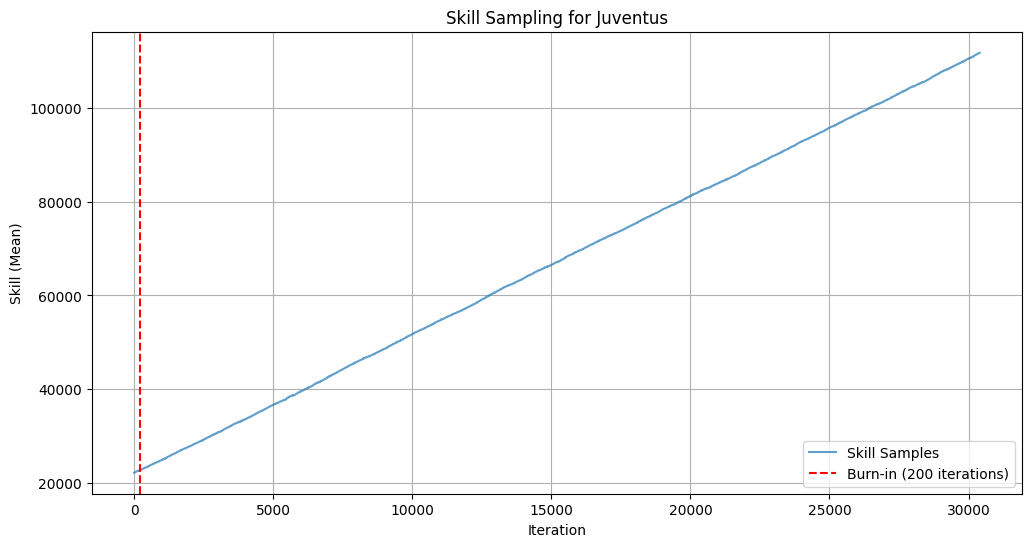

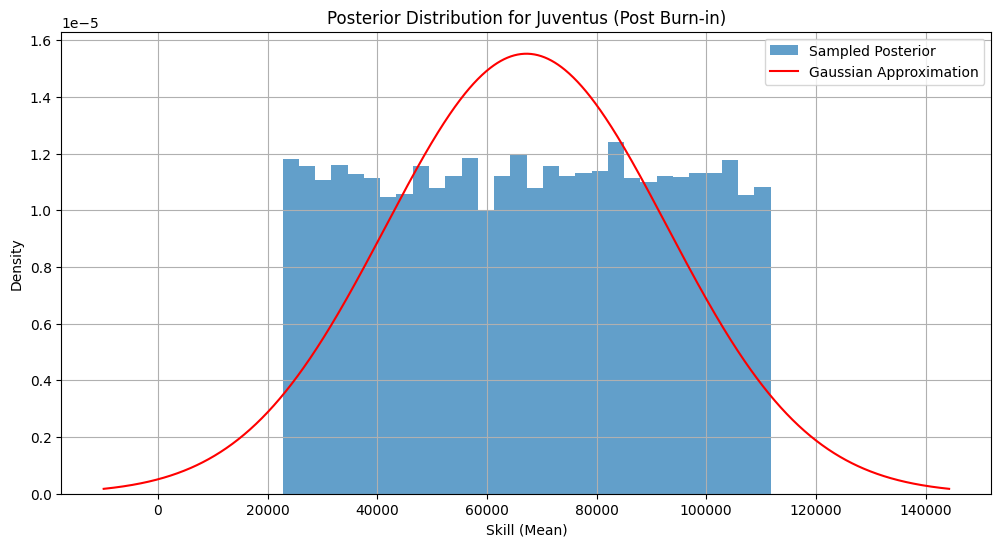

In [13]:
# load necessary libraries 
import pandas as pd
import numpy as np
from scipy.stats import truncnorm, norm
import matplotlib.pyplot as plt
import time
from sklearn.metrics import accuracy_score


# load SerieA dataset
file_path = 'SerieA.csv'
matches = pd.read_csv(file_path)

# Prepare the dataset for TrueSkill analysis
matches['result'] = matches['score1'] - matches['score2']
matches['outcome'] = matches['result'].apply(lambda x: 1 if x > 0 else (-1 if x < 0 else 0))
matches = matches[['team1', 'team2', 'outcome']]

# Gibbs Sampling Implementation
def gibbs_sampling(matches, iterations=1000, burn_in=200):
    MU0 = 25.0  # Initial mean skill
    SIGMA0 = 8.333  # Initial standard deviation
    SIGMA_T = 1.0  # Outcome variance

    # Initialize skill priors
    skills = {team: {'mu': MU0, 'sigma': SIGMA0} for team in set(matches['team1']).union(matches['team2'])}
    skill_samples = {team: [] for team in skills}

    for it in range(iterations):
        for _, row in matches.iterrows():
            team1, team2, outcome = row['team1'], row['team2'], row['outcome']
            mu1, sigma1 = skills[team1]['mu'], skills[team1]['sigma']
            mu2, sigma2 = skills[team2]['mu'], skills[team2]['sigma']

            # Step 1: Sample t (Skill difference)
            delta_sigma = np.sqrt(sigma1**2 + sigma2**2 + SIGMA_T**2)
            if outcome == 1:  # Home win
                t = truncnorm.rvs(0, np.inf, loc=mu1 - mu2, scale=delta_sigma)
            elif outcome == -1:  # Away win
                t = truncnorm.rvs(-np.inf, 0, loc=mu1 - mu2, scale=delta_sigma)
            else:  # Draw
                t = norm.rvs(loc=mu1 - mu2, scale=delta_sigma)

            # Step 2: Update skills
            v = (t - (mu1 - mu2)) / delta_sigma
            skills[team1]['mu'] += (sigma1**2 / delta_sigma) * v
            skills[team2]['mu'] -= (sigma2**2 / delta_sigma) * v

            # Save samples after burn-in
            if it >= burn_in:
                skill_samples[team1].append(skills[team1]['mu'])
                skill_samples[team2].append(skills[team2]['mu'])

    return skills, skill_samples

# Run Gibbs Sampling
ITERATIONS = 1000  # Total iterations
BURN_IN = 200  # Burn-in period
final_skills, skill_samples = gibbs_sampling(matches, iterations=ITERATIONS, burn_in=BURN_IN)

# Plotting and Analysis Functions
def plot_skill_samples(skill_samples, team_name, burn_in=200):
    """Plot skill samples for a specific team."""
    samples = skill_samples[team_name]
    post_burn_samples = samples[burn_in:]
    
    # Plotting skill samples
    plt.figure(figsize=(12, 6))
    plt.plot(samples, label='Skill Samples', alpha=0.7)
    plt.axvline(burn_in, color='red', linestyle='--', label=f'Burn-in ({burn_in} iterations)')
    plt.title(f"Skill Sampling for {team_name}")
    plt.xlabel("Iteration")
    plt.ylabel("Skill (Mean)")
    plt.legend()
    plt.grid()
    plt.show()
    
    # Histogram of post-burn-in samples
    plt.figure(figsize=(12, 6))
    plt.hist(post_burn_samples, bins=30, density=True, alpha=0.7, label="Sampled Posterior")
    
    # Overlay Gaussian approximation
    mean = np.mean(post_burn_samples)
    std_dev = np.std(post_burn_samples)
    x = np.linspace(mean - 3 * std_dev, mean + 3 * std_dev, 1000)
    gaussian_approx = norm.pdf(x, loc=mean, scale=std_dev)
    plt.plot(x, gaussian_approx, label="Gaussian Approximation", color="red")
    
    plt.title(f"Posterior Distribution for {team_name} (Post Burn-in)")
    plt.xlabel("Skill (Mean)")
    plt.ylabel("Density")
    plt.legend()
    plt.grid()
    plt.show()

# Example: Plot for a specific team
team_name = "Juventus"  # Replace with any team name from the dataset
plot_skill_samples(skill_samples, team_name=team_name, burn_in=BURN_IN)

# Function to evaluate accuracy vs. time for different sample sizes
def evaluate_accuracy_vs_time(matches, skill_samples, burn_in, sample_sizes):
    results = []

    for n_samples in sample_sizes:
        start_time = time.time()

        # Estimate skills using the mean of `n_samples` post-burn-in samples
        skills = {
            team: np.mean(skill_samples[team][burn_in:burn_in + n_samples])
            for team in skill_samples
        }

        # Predict match outcomes based on sampled skills
        predictions = []
        for _, row in matches.iterrows():
            team1, team2 = row['team1'], row['team2']
            if skills[team1] > skills[team2]:
                predictions.append(1)  # Home win
            elif skills[team1] < skills[team2]:
                predictions.append(-1)  # Away win
            else:
                predictions.append(0)  # Draw

        # Calculate accuracy
        accuracy = accuracy_score(matches['outcome'], predictions)
        elapsed_time = time.time() - start_time

        # Append results
        results.append({'Samples': n_samples, 'Accuracy': accuracy, 'Time': elapsed_time})

    return pd.DataFrame(results)

# Define sample sizes to evaluate
sample_sizes = [50, 100, 200, 500]




Samples: 500, Avg Time: 0.000670 seconds, Accuracy: 0.5500
Samples: 200, Avg Time: 0.000366 seconds, Accuracy: 0.5500
Samples: 100, Avg Time: 0.000270 seconds, Accuracy: 0.5500
Samples: 50, Avg Time: 0.000179 seconds, Accuracy: 0.5500


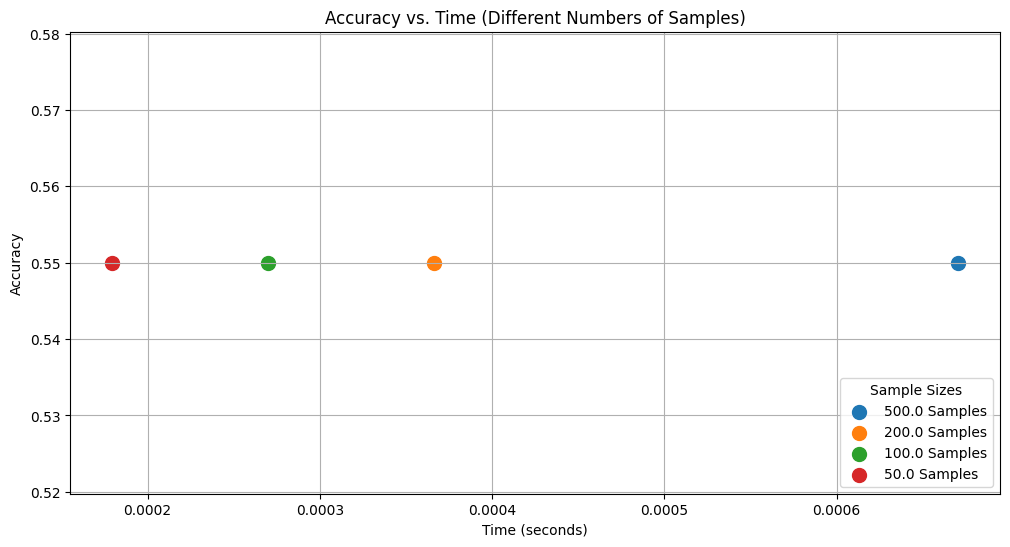

In [25]:
def evaluate_accuracy_vs_time(matches, skill_samples, burn_in, sample_sizes, num_runs=5):
    results = []

    for n_samples in sample_sizes:
        total_time = 0

        for _ in range(num_runs):  # Repeat multiple runs
            start_time = time.perf_counter()

            # Core computation
            skills = {
                team: np.mean(skill_samples[team][burn_in:burn_in + n_samples])
                for team in skill_samples
            }

            total_time += time.perf_counter() - start_time

        # Average time over multiple runs
        elapsed_time = total_time / num_runs

        # Predict match outcomes
        predictions = []
        for _, row in matches.iterrows():
            team1, team2 = row['team1'], row['team2']
            if skills[team1] > skills[team2]:
                predictions.append(1)  # Team 1 wins
            elif skills[team1] < skills[team2]:
                predictions.append(-1)  # Team 2 wins
            else:
                predictions.append(0)  # Draw

        # Compute accuracy
        accuracy = accuracy_score(matches['outcome'], predictions)

        # Append results
        results.append({'Samples': n_samples, 'Accuracy': accuracy, 'Time': elapsed_time})

        print(f"Samples: {n_samples}, Avg Time: {elapsed_time:.6f} seconds, Accuracy: {accuracy:.4f}")

    return pd.DataFrame(results)


# Define sample sizes to evaluate
sample_sizes = [500, 200, 100, 50]

# Run the evaluation function
results_df = evaluate_accuracy_vs_time(matches, skill_samples, burn_in=200, sample_sizes=sample_sizes)

# Plot Accuracy vs. Time for Different Sample Sizes
plt.figure(figsize=(12, 6))
for _, row in results_df.iterrows():
    plt.scatter(row['Time'], row['Accuracy'], label=f"{row['Samples']} Samples", s=100)  # Scatter points


plt.xlabel('Time (seconds)')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. Time (Different Numbers of Samples)')
plt.legend(loc='lower right', title="Sample Sizes")
plt.grid()
plt.show()


In [32]:
import pandas as pd
import numpy as np
from scipy.stats import norm

# Load the dataset
data = pd.read_csv('SerieA.csv')

# Inspect the dataset
print("Columns in the dataset:", data.columns.tolist())
print(data.head())

# Map existing column names to expected names
data.rename(columns={'team1': 'Team1', 'team2': 'Team2', 'score1': 'Score1', 'score2': 'Score2'}, inplace=True)

# Add a 'Result' column based on scores
data['Result'] = np.where(data['Score1'] > data['Score2'], 1, 
                 np.where(data['Score1'] < data['Score2'], -1, 0))

# Filter out draws
data = data[data['Result'] != 0]

# Initialize team skills
teams = pd.unique(data[['Team1', 'Team2']].values.ravel())
skills = {team: {'mu': 25, 'sigma2': 8.33} for team in teams}

# Define ADF update function
def adf_update(team1, team2, result, skills, sigma_t=1.0):
    mu1, sigma2_1 = skills[team1]['mu'], skills[team1]['sigma2']
    mu2, sigma2_2 = skills[team2]['mu'], skills[team2]['sigma2']
    
    # Skill difference distribution
    mean_diff = mu1 - mu2
    var_diff = sigma2_1 + sigma2_2 + sigma_t**2

    # Outcome likelihood and posterior update
    if result == 1:  # Team 1 wins
        outcome_prob = norm.cdf(mean_diff / np.sqrt(var_diff))
        gradient = norm.pdf(mean_diff / np.sqrt(var_diff)) / outcome_prob
    elif result == -1:  # Team 2 wins
        outcome_prob = 1 - norm.cdf(mean_diff / np.sqrt(var_diff))
        gradient = -norm.pdf(mean_diff / np.sqrt(var_diff)) / outcome_prob
    else:
        raise ValueError("Result must be 1 (Team1 wins) or -1 (Team2 wins)")

    # Update skills
    delta = gradient / np.sqrt(var_diff)
    skills[team1]['mu'] += sigma2_1 * delta
    skills[team2]['mu'] -= sigma2_2 * delta
    skills[team1]['sigma2'] *= (1 - (sigma2_1 / var_diff))
    skills[team2]['sigma2'] *= (1 - (sigma2_2 / var_diff))

# Process matches sequentially
for _, row in data.iterrows():
    adf_update(row['Team1'], row['Team2'], row['Result'], skills)

# Rank teams by final skill estimates
final_ranking = sorted(skills.items(), key=lambda x: x[1]['mu'], reverse=True)

# Display final rankings
print("Final Rankings:")
for rank, (team, stats) in enumerate(final_ranking, 1):
    print(f"{rank}. {team}: μ={stats['mu']:.2f}, σ²={stats['sigma2']:.2f}")


# Shuffle matches and re-run ADF
shuffled_data = data.sample(frac=1, random_state=42)
for team in skills:
    skills[team] = {'mu': 25, 'sigma2': 8.33}  # Reset skills
for _, row in shuffled_data.iterrows():
    if row['Result'] != 0:  # Skip draws
        adf_update(row['Team1'], row['Team2'], row['Result'], skills)

# Re-rank after shuffled processing
shuffled_ranking = sorted(skills.items(), key=lambda x: x[1]['mu'], reverse=True)

# Display shuffled rankings
print("\nRankings After Shuffled Matches:")
for rank, (team, stats) in enumerate(shuffled_ranking, 1):
    print(f"{rank}. {team}: μ={stats['mu']:.2f}, σ²={stats['sigma2']:.2f}")


Columns in the dataset: ['yyyy-mm-dd', 'HH:MM', 'team1', 'team2', 'score1', 'score2']
   yyyy-mm-dd  HH:MM     team1     team2  score1  score2
0  18-08-2018  18:00    Chievo  Juventus       2       3
1  18-08-2018  20:30     Lazio    Napoli       1       2
2  19-08-2018  18:00    Torino      Roma       0       1
3  19-08-2018  20:30  Sassuolo     Inter       1       0
4  19-08-2018  20:30     Parma   Udinese       2       2
Final Rankings:
1. Juventus: μ=27.57, σ²=0.04
2. Napoli: μ=26.59, σ²=0.04
3. Milan: μ=26.22, σ²=0.05
4. Inter: μ=25.75, σ²=0.04
5. Torino: μ=25.53, σ²=0.05
6. Atalanta: μ=25.20, σ²=0.04
7. Lazio: μ=25.15, σ²=0.04
8. Roma: μ=25.14, σ²=0.05
9. Sassuolo: μ=25.08, σ²=0.06
10. Sampdoria: μ=24.98, σ²=0.04
11. Genoa: μ=24.79, σ²=0.06
12. Fiorentina: μ=24.78, σ²=0.06
13. Parma: μ=24.68, σ²=0.05
14. Spal: μ=24.58, σ²=0.05
15. Cagliari: μ=24.38, σ²=0.05
16. Udinese: μ=24.22, σ²=0.04
17. Empoli: μ=24.18, σ²=0.04
18. Bologna: μ=24.13, σ²=0.05
19. Frosinone: μ=22.97, σ²=0.05
20.

In [34]:
import pandas as pd
import numpy as np
from scipy.stats import norm

# Load the dataset
data = pd.read_csv('SerieA.csv')

# Rename columns to expected names
data.rename(columns={'team1': 'Team1', 'team2': 'Team2', 'score1': 'Score1', 'score2': 'Score2'}, inplace=True)

# Create 'Result' column
data['Result'] = np.where(data['Score1'] > data['Score2'], 1,
                 np.where(data['Score1'] < data['Score2'], -1, 0))

# Filter out draws
data = data[data['Result'] != 0]

# Initialize team skills
teams = pd.unique(data[['Team1', 'Team2']].values.ravel())
skills = {team: {'mu': 25, 'sigma2': 8.33} for team in teams}

# Define ADF update function
def adf_update(team1, team2, result, skills, sigma_t=1.0):
    mu1, sigma2_1 = skills[team1]['mu'], skills[team1]['sigma2']
    mu2, sigma2_2 = skills[team2]['mu'], skills[team2]['sigma2']
    
    # Skill difference distribution
    mean_diff = mu1 - mu2
    var_diff = sigma2_1 + sigma2_2 + sigma_t**2

    # Outcome likelihood and posterior update
    if result == 1:  # Team 1 wins
        outcome_prob = norm.cdf(mean_diff / np.sqrt(var_diff))
        gradient = norm.pdf(mean_diff / np.sqrt(var_diff)) / outcome_prob
    elif result == -1:  # Team 2 wins
        outcome_prob = 1 - norm.cdf(mean_diff / np.sqrt(var_diff))
        gradient = -norm.pdf(mean_diff / np.sqrt(var_diff)) / outcome_prob
    else:
        raise ValueError("Result must be 1 (Team1 wins) or -1 (Team2 wins)")

    # Update skills
    delta = gradient / np.sqrt(var_diff)
    skills[team1]['mu'] += sigma2_1 * delta
    skills[team2]['mu'] -= sigma2_2 * delta
    skills[team1]['sigma2'] *= (1 - (sigma2_1 / var_diff))
    skills[team2]['sigma2'] *= (1 - (sigma2_2 / var_diff))

# Define prediction function
def predict_winner(team1, team2, skills, sigma_t=1.0):
    mu1, sigma2_1 = skills[team1]['mu'], skills[team1]['sigma2']
    mu2, sigma2_2 = skills[team2]['mu'], skills[team2]['sigma2']
    mean_diff = mu1 - mu2
    var_diff = sigma2_1 + sigma2_2 + sigma_t**2
    prob_team1_wins = norm.cdf(mean_diff / np.sqrt(var_diff))
    return 1 if prob_team1_wins > 0.5 else -1

# Perform one-step-ahead predictions
correct_predictions = 0
total_predictions = 0

for _, row in data.iterrows():
    predicted_result = predict_winner(row['Team1'], row['Team2'], skills)
    actual_result = row['Result']
    if predicted_result == actual_result:
        correct_predictions += 1
    total_predictions += 1
    # Update skills after prediction
    adf_update(row['Team1'], row['Team2'], actual_result, skills)

# Calculate one-step-ahead prediction accuracy
model_accuracy = correct_predictions / total_predictions

# Random guessing accuracy
random_guess_accuracy = 0.5

# Display results
print(f"One-step-ahead prediction accuracy: {model_accuracy:.2%}")
print(f"Random guessing accuracy: {random_guess_accuracy:.2%}")
print(f"Improvement over random guessing: {model_accuracy - random_guess_accuracy:.2%}")


One-step-ahead prediction accuracy: 64.71%
Random guessing accuracy: 50.00%
Improvement over random guessing: 14.71%


Updated skill for Team 1: μ=25.38, σ=2.10
Updated skill for Team 2: μ=24.62, σ=2.10


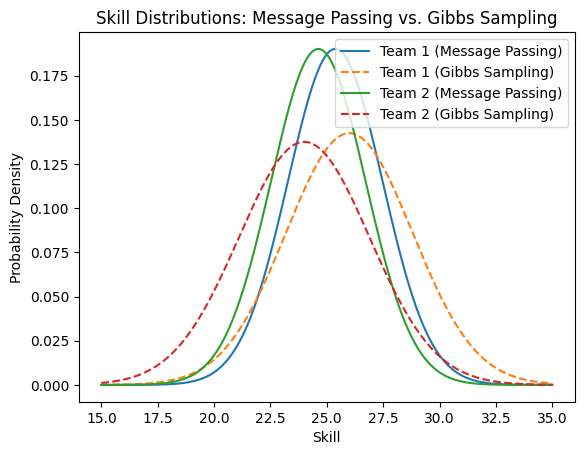

In [35]:
import numpy as np
from scipy.stats import norm

# Initialize prior distributions for skills
mu1, sigma1 = 25, np.sqrt(8.33)
mu2, sigma2 = 25, np.sqrt(8.33)
sigma_t = 1.0  # Performance variability

# Skill difference distribution
def skill_difference_message(mu1, sigma1, mu2, sigma2):
    mean_diff = mu1 - mu2
    var_diff = sigma1**2 + sigma2**2 + sigma_t**2
    return mean_diff, var_diff

# Outcome likelihood message
def outcome_message(mean_diff, var_diff, result):
    if result == 1:  # Team 1 wins
        truncation = mean_diff / np.sqrt(var_diff)
        prob = norm.cdf(truncation)
        mean_adj = norm.pdf(truncation) / prob
    elif result == -1:  # Team 2 wins
        truncation = -mean_diff / np.sqrt(var_diff)
        prob = norm.cdf(truncation)
        mean_adj = -norm.pdf(truncation) / prob
    else:
        raise ValueError("Result must be 1 or -1")
    var_adj = 1 - mean_adj * truncation
    return mean_adj, var_adj

# Update skills using message passing
def message_passing_update(mu1, sigma1, mu2, sigma2, result):
    # Compute skill difference
    mean_diff, var_diff = skill_difference_message(mu1, sigma1, mu2, sigma2)
    
    # Compute adjustment from outcome
    mean_adj, var_adj = outcome_message(mean_diff, var_diff, result)
    
    # Adjust skills
    delta1 = (sigma1**2 / var_diff) * mean_adj
    delta2 = (sigma2**2 / var_diff) * mean_adj
    mu1 += delta1
    mu2 -= delta2
    sigma1 = np.sqrt(sigma1**2 * (1 - sigma1**2 / var_diff))
    sigma2 = np.sqrt(sigma2**2 * (1 - sigma2**2 / var_diff))
    return mu1, sigma1, mu2, sigma2

# Perform message passing for one match
result = 1  # Assume Team 1 wins
mu1, sigma1, mu2, sigma2 = message_passing_update(mu1, sigma1, mu2, sigma2, result)

print(f"Updated skill for Team 1: μ={mu1:.2f}, σ={sigma1:.2f}")
print(f"Updated skill for Team 2: μ={mu2:.2f}, σ={sigma2:.2f}")

# Compare with Gibbs Sampling
# Assume Gibbs sampling outputs
gibbs_mu1, gibbs_sigma1 = 26, 2.8  # Example values
gibbs_mu2, gibbs_sigma2 = 24, 2.9  # Example values

# Plot comparison
import matplotlib.pyplot as plt

x = np.linspace(15, 35, 500)

# Message passing distributions
mp_team1 = norm.pdf(x, mu1, sigma1)
mp_team2 = norm.pdf(x, mu2, sigma2)

# Gibbs sampling distributions
gibbs_team1 = norm.pdf(x, gibbs_mu1, gibbs_sigma1)
gibbs_team2 = norm.pdf(x, gibbs_mu2, gibbs_sigma2)

plt.plot(x, mp_team1, label="Team 1 (Message Passing)")
plt.plot(x, gibbs_team1, label="Team 1 (Gibbs Sampling)", linestyle="dashed")
plt.plot(x, mp_team2, label="Team 2 (Message Passing)")
plt.plot(x, gibbs_team2, label="Team 2 (Gibbs Sampling)", linestyle="dashed")
plt.title("Skill Distributions: Message Passing vs. Gibbs Sampling")
plt.xlabel("Skill")
plt.ylabel("Probability Density")
plt.legend()
plt.show()
